In [1]:
## Définition de votre zone d'étude
# Voici les limites géographiques que nous utiliserons pour l’Afrique de l’Ouest :
#__________________________________________________________

###bounds = {

    ###'x': (-16.0, 12.0),   #  De la côte de la Guinée-Bissau à la frontière du Nigeria 

    ###'y': (  4.0, 12.0)    # Du golfe de Guinée jusqu'au Sahel  

###}

#__________________________________________________________

#Chaque module se concentrera sur une zone d’intérêt (AOI) plus spécifique à l’intérieur de ces limites, par exemple:

# Module 2.1: grille de perte pour l’ensemble de l’Afrique de l’Ouest
# Module 2.2: côte de la Guinée-Bissau
# Module 2.3: Tunisie (Sidi Bouzid)
# Module 2.4: Freetown ou une autre ville d’Afrique de l’Ouest

In [2]:
## 2.1.2 Charger les packages
#____________________________________________________________
# Charger les packages Python nécessaires

%matplotlib inline



import datacube                                    # API d'accès aux données de DE Africa

import numpy as np                                 # Opérations numériques

import matplotlib.pyplot as plt                    # Bibliothèque de visualisation

import matplotlib.ticker as mticker                # Pour formater les axes des graphiques

from deafrica_tools.plotting import display_map, plot_lulc  # Fonctions utilitaires de DE Africa
#____________________________________________________________

In [3]:
##2.1.3 Se connecter au Datacube
#____________________________________________________________

# Initialiser la connexion au Datacube

dc = datacube.Datacube(app="deforestation_hotspots_module")

# Vous pouvez maintenant interroger n’importe quel produit DE Africa enregistré dans le cube

#____________________________________________________________

# Si la connexion est réussie, vous pouvez désormais interroger n'importe quel produit DE Africa disponible dans le bac à sable. Cela permet d'établir les bases de tous les chargements de données et analyses ultérieurs, en garantissant l'obtention d'ensembles de données gérés de manière cohérente.

In [4]:
## 2.1.4 Lister les mesures disponibles
#____________________________________________________________

# Examiner les bandes disponibles pour les principaux produits LULC

product_names = [

    'io_lulc_v2', 'esa_worldcover_2020', 

    'esa_worldcover_2021', 'cgls_landcover', 'cci_landcover'

]


# Récupérer les métadonnées des mesures pour ces produits

dc_measurements = dc.list_measurements().loc[product_names]

 

# Supprimer la colonne des définitions de drapeaux (flags) pour plus de lisibilité

dc_measurements.drop(columns=['flags_definition'], inplace=True)

 

# Afficher le tableau des produits, bandes et types de données

display(dc_measurements)

#____________________________________________________________

# Le tableau présente les bandes disponibles et les types de données pour chaque produit. Aucun ne fournit explicitement les années de perte forestière à l’échelle du pixel ; ils se contentent de classer l’occupation du sol à des dates données. Pour identifier directement les « points chauds » de déforestation, il faut un produit qui indique les années de perte par pixel ; sinon, il faut faire la différence manuellement entre les années, ce qui peut introduire des erreurs 🧐.

# Le tableau présente les bandes et les types de données disponibles pour chaque produit.

#io_lulc_v2: une seule valeur entière  « classification »  par pixel, basée sur une composition multi-annuelle.
#esa_worldcover_*: classification annuelle à une résolution de 10 m.
#Les autres produits disponibles fournissent également uniquement des instantanés annuels.
#Aucun d'entre eux n’indique directement des événements de perte ou de gain de couverture forestière, ce qui signifie que la détection des points chauds nécessite une comparaison manuelle d’années consécutives — une méthode sujette à erreurs.

name  \
product             measurement                                                    
io_lulc_v2          supercell                                          supercell   
esa_worldcover_2020 classification                                classification   
esa_worldcover_2021 classification                                classification   
cgls_landcover      classification                                classification   
                    forest_type                                      forest_type   
                    classification_probability        classification_probability   
                    bare_cover_fraction                      bare_cover_fraction   
                    builtup_cover_fraction                builtup_cover_fraction   
                    crops_cover_fraction                    crops_cover_fraction   
                    grass_cover_fraction                    grass_cover_fraction   
                    mosslichen_cover_fraction          mosslichen_cover_fraction   
                    permanentwater_cover_fraction  permanentwater_cover_fraction   
                    seasonalwater_cover_fraction    seasonalwater_cover_fraction   
                    shrub_cover_fraction                    shrub_cover_fraction   
                    snow_cover_fraction                      snow_cover_fraction   
                    tree_cover_fraction                      tree_cover_fraction   
cci_landcover       classification                                classification   

                                                   dtype    units  nodata  \
product             measurement                                             
io_lulc_v2          supercell                      uint8        1     0.0   
esa_worldcover_2020 classification                 uint8        1     0.0   
esa_worldcover_2021 classification                 uint8        1     0.0   
cgls_landcover      classification                 uint8        1   255.0   
                    forest_type                    uint8  percent   255.0   
                    classification_probability     uint8  percent   255.0   
                    bare_cover_fraction            uint8  percent   255.0   
                    builtup_cover_fraction         uint8  percent   255.0   
                    crops_cover_fraction           uint8  percent   255.0   
                    grass_cover_fraction           uint8  percent   255.0   
                    mosslichen_cover_fraction      uint8  percent   255.0   
                    permanentwater_cover_fraction  uint8  percent   255.0   
                    seasonalwater_cover_fraction   uint8  percent   255.0   
                    shrub_cover_fraction           uint8  percent   255.0   
                    snow_cover_fraction            uint8  percent   255.0   
                    tree_cover_fraction            uint8  percent   255.0   
cci_landcover       classification                 uint8        1     0.0   

                                                            aliases  \
product             measurement                                       
io_lulc_v2          supercell                      [classification]   
esa_worldcover_2020 classification                              NaN   
esa_worldcover_2021 classification                              NaN   
cgls_landcover      classification                          [class]   
                    forest_type                                  []   
                    classification_probability               [prob]   
                    bare_cover_fraction                      [bare]   
                    builtup_cover_fraction                [builtup]   
                    crops_cover_fraction                    [crops]   
                    grass_cover_fraction                    [grass]   
                    mosslichen_cover_fraction          [mosslichen]   
                    permanentwater_cover_fraction  [permanentwater]   
                    s

In [5]:
## 2.1.5 Définir les paramètres d’analyse
#____________________________________________________________

# Définir les paramètres d’analyse par défaut (ex.: Madagascar)

lat, lon, buffer = -19.4557, 46.4644, 5.0  # point central et zone tampon en degrés

resolution = (-500, 500)                   # reéchantillonner à 500 m pour un affichage rapide

 

# Calculer la boîte englobante à partir du point central et de la zone tampon

lons = (lon - buffer, lon + buffer)

lats = (lat - buffer, lat + buffer)

 

# Charger la mesure de LULC 
measurements = 'classification'

#____________________________________________________________

#Ces paramètres définissent une fenêtre de visualisation rapide autour de Madagascar pour une exploration initiale. La grille à 500 m permet d'afficher rapidement les grandes tendances de la couverture terrestre tout en conservant une bonne résolution.

In [6]:
## 2.1.6 Charger et inspecter les jeux de données LULC
#____________________________________________________________

# Charger IO LULC v2 (2020)

query = {

    'time': '2020-07',           # mi-année pour éviter les problèmes liés aux limites temporelles 

    'x': lons,                   # bornes de longitude 

    'y': lats,                   # bornes de latitude

    'resolution': resolution,    # résolution spatiales

    'output_crs': 'EPSG:6933',   # projection en surface équivalente 

    'measurements': measurements # bande à extraire 

}

ds_io = dc.load(product='io_lulc_v2', **query).squeeze()
print(ds_io)  # afficher les métadonnées et la structure du jeu de données 

#____________________________________________________________

# (Répétez le chargement pour ESA WorldCover 2020 & 2021, CGLS 2019 et CCI 2019 en utilisant la même URL like=ds_io.geobox.)

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 2407, x: 1931)
Coordinates:
  * y               (y) float64 19kB -1.825e+06 -1.826e+06 ... -3.028e+06
  * x               (x) float64 15kB 4.001e+06 4.001e+06 ... 4.965e+06 4.966e+06
    time            datetime64[ns] 8B 2020-07-01T23:59:59.997500
    spatial_ref     int32 4B 6933
Data variables:
    classification  (y, x) uint8 5MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


In [7]:
## 2.1.5 Définir les paramètres d’analyse
#____________________________________________________________

# Définir les paramètres d’analyse par défaut (ex.: Madagascar)

lat, lon, buffer = -19.4557, 46.4644, 5.0  # point central et zone tampon en degrés

resolution = (-500, 500)                   # reéchantillonner à 500 m pour un affichage rapide

 

# Calculer la boîte englobante à partir du point central et de la zone tampon

lons = (lon - buffer, lon + buffer)

lats = (lat - buffer, lat + buffer)

 

# Charger la mesure de esa_worldcover_2020
measurements = 'classification'

#____________________________________________________________

In [8]:
## 2.1.6 Charger et inspecter les jeux de données ESA WorldCover 2020
#____________________________________________________________

# Charger esa_worldcover_2020

query = {

    'time': '2020-07',           # mi-année pour éviter les problèmes liés aux limites temporelles 

    'x': lons,                   # bornes de longitude 

    'y': lats,                   # bornes de latitude

    'resolution': resolution,    # résolution spatiales

    'output_crs': 'EPSG:6933',   # projection en surface équivalente 

    'measurements': measurements # bande à extraire 

}

ds_esa_2020 = dc.load(product='esa_worldcover_2020', **query).squeeze()
print(ds_esa_2020)  # afficher les métadonnées et la structure du jeu de données 

#____________________________________________________________

# (Répétez le chargement pour ESA WorldCover 2020 & 2021, CGLS 2019 et CCI 2019 en utilisant la même URL like=ds_io.geobox.)

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 2407, x: 1931)
Coordinates:
  * y               (y) float64 19kB -1.825e+06 -1.826e+06 ... -3.028e+06
  * x               (x) float64 15kB 4.001e+06 4.001e+06 ... 4.965e+06 4.966e+06
    time            datetime64[ns] 8B 2020-07-01T12:00:00
    spatial_ref     int32 4B 6933
Data variables:
    classification  (y, x) uint8 5MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


In [9]:
## 2.1.5 Définir les paramètres d’analyse
#____________________________________________________________

# Définir les paramètres d’analyse par défaut (ex.: Madagascar)

lat, lon, buffer = -19.4557, 46.4644, 5.0  # point central et zone tampon en degrés

resolution = (-500, 500)                   # reéchantillonner à 500 m pour un affichage rapide

 

# Calculer la boîte englobante à partir du point central et de la zone tampon

lons = (lon - buffer, lon + buffer)

lats = (lat - buffer, lat + buffer)

 

# Charger la mesure de esa_worldcover_2020
measurements = 'classification'

#____________________________________________________________

In [10]:
## 2.1.6 Charger et inspecter les jeux de données ESA WorldCover 2021
#____________________________________________________________

# Charger esa_worldcover_2021

query = {

    'time': '2021-07',           # mi-année pour éviter les problèmes liés aux limites temporelles 

    'x': lons,                   # bornes de longitude 

    'y': lats,                   # bornes de latitude

    'resolution': resolution,    # résolution spatiales

    'output_crs': 'EPSG:6933',   # projection en surface équivalente 

    'measurements': measurements # bande à extraire 

}

ds_esa_2021 = dc.load(product='esa_worldcover_2021', **query).squeeze()
print(ds_esa_2021)  # afficher les métadonnées et la structure du jeu de données 

#____________________________________________________________

# (Répétez le chargement pour ESA WorldCover 2020 & 2021, CGLS 2019 et CCI 2019 en utilisant la même URL like=ds_io.geobox.)

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 2407, x: 1931)
Coordinates:
  * y               (y) float64 19kB -1.825e+06 -1.826e+06 ... -3.028e+06
  * x               (x) float64 15kB 4.001e+06 4.001e+06 ... 4.965e+06 4.966e+06
    time            datetime64[ns] 8B 2021-07-02
    spatial_ref     int32 4B 6933
Data variables:
    classification  (y, x) uint8 5MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


In [11]:
## 2.1.5 Définir les paramètres d’analyse
#____________________________________________________________

# Définir les paramètres d’analyse par défaut (ex.: Madagascar)

lat, lon, buffer = -19.4557, 46.4644, 5.0  # point central et zone tampon en degrés

resolution = (-500, 500)                   # reéchantillonner à 500 m pour un affichage rapide

 

# Calculer la boîte englobante à partir du point central et de la zone tampon

lons = (lon - buffer, lon + buffer)

lats = (lat - buffer, lat + buffer)

 

# Charger la mesure de cgls_landcover
measurements = 'classification'

#____________________________________________________________

#Ces paramètres définissent une fenêtre de visualisation rapide autour de Madagascar pour une exploration initiale. La grille à 500 m permet d'afficher rapidement les grandes tendances de la couverture terrestre tout en conservant une bonne résolution.

In [12]:
## 2.1.6 Charger et inspecter les jeux de données cgls_landcover 2019
#____________________________________________________________

# Charger cgls_landcover_2019

query = {

    'time': '2019-07',           # mi-année pour éviter les problèmes liés aux limites temporelles 

    'x': lons,                   # bornes de longitude 

    'y': lats,                   # bornes de latitude

    'resolution': resolution,    # résolution spatiales

    'output_crs': 'EPSG:6933',   # projection en surface équivalente 

    'measurements': measurements # bande à extraire 

}

ds_cgls = dc.load(product='cgls_landcover', **query).squeeze()
print(ds_cgls)  # afficher les métadonnées et la structure du jeu de données 

#____________________________________________________________

# (Répétez le chargement pour ESA WorldCover 2020 & 2021, CGLS 2019 et CCI 2019 en utilisant la même URL like=ds_io.geobox.)

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 2407, x: 1931)
Coordinates:
  * y               (y) float64 19kB -1.825e+06 -1.826e+06 ... -3.028e+06
  * x               (x) float64 15kB 4.001e+06 4.001e+06 ... 4.965e+06 4.966e+06
    time            datetime64[ns] 8B 2019-07-02T11:59:59.500000
    spatial_ref     int32 4B 6933
Data variables:
    classification  (y, x) uint8 5MB 200 200 200 200 200 ... 200 200 200 200 200
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


In [13]:
## 2.1.5 Définir les paramètres d’analyse
#____________________________________________________________

# Définir les paramètres d’analyse par défaut (ex.: Madagascar)

lat, lon, buffer = -19.4557, 46.4644, 5.0  # point central et zone tampon en degrés

resolution = (-500, 500)                   # reéchantillonner à 500 m pour un affichage rapide

 

# Calculer la boîte englobante à partir du point central et de la zone tampon

lons = (lon - buffer, lon + buffer)

lats = (lat - buffer, lat + buffer)

 

# Charger la mesure de 'cci_landcover'
measurements = 'classification'

#____________________________________________________________

#Ces paramètres définissent une fenêtre de visualisation rapide autour de Madagascar pour une exploration initiale. La grille à 500 m permet d'afficher rapidement les grandes tendances de la couverture terrestre tout en conservant une bonne résolution.

In [14]:
## 2.1.6 Charger et inspecter les jeux de données cci_landcover 2019
#____________________________________________________________

# Charger cci_landcover_2019

query = {

    'time': '2019-07',           # mi-année pour éviter les problèmes liés aux limites temporelles 

    'x': lons,                   # bornes de longitude 

    'y': lats,                   # bornes de latitude

    'resolution': resolution,    # résolution spatiales

    'output_crs': 'EPSG:6933',   # projection en surface équivalente 

    'measurements': measurements # bande à extraire 

}

ds_cci = dc.load(product='cci_landcover', **query).squeeze()
print(ds_cci)  # afficher les métadonnées et la structure du jeu de données 

#____________________________________________________________

# (Répétez le chargement pour ESA WorldCover 2020 & 2021, CGLS 2019 et CCI 2019 en utilisant la même URL like=ds_io.geobox.)

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 2407, x: 1931)
Coordinates:
  * y               (y) float64 19kB -1.825e+06 -1.826e+06 ... -3.028e+06
  * x               (x) float64 15kB 4.001e+06 4.001e+06 ... 4.965e+06 4.966e+06
    time            datetime64[ns] 8B 2019-07-02T11:59:59.500000
    spatial_ref     int32 4B 6933
Data variables:
    classification  (y, x) uint8 5MB 210 210 210 210 210 ... 210 210 210 210 210
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


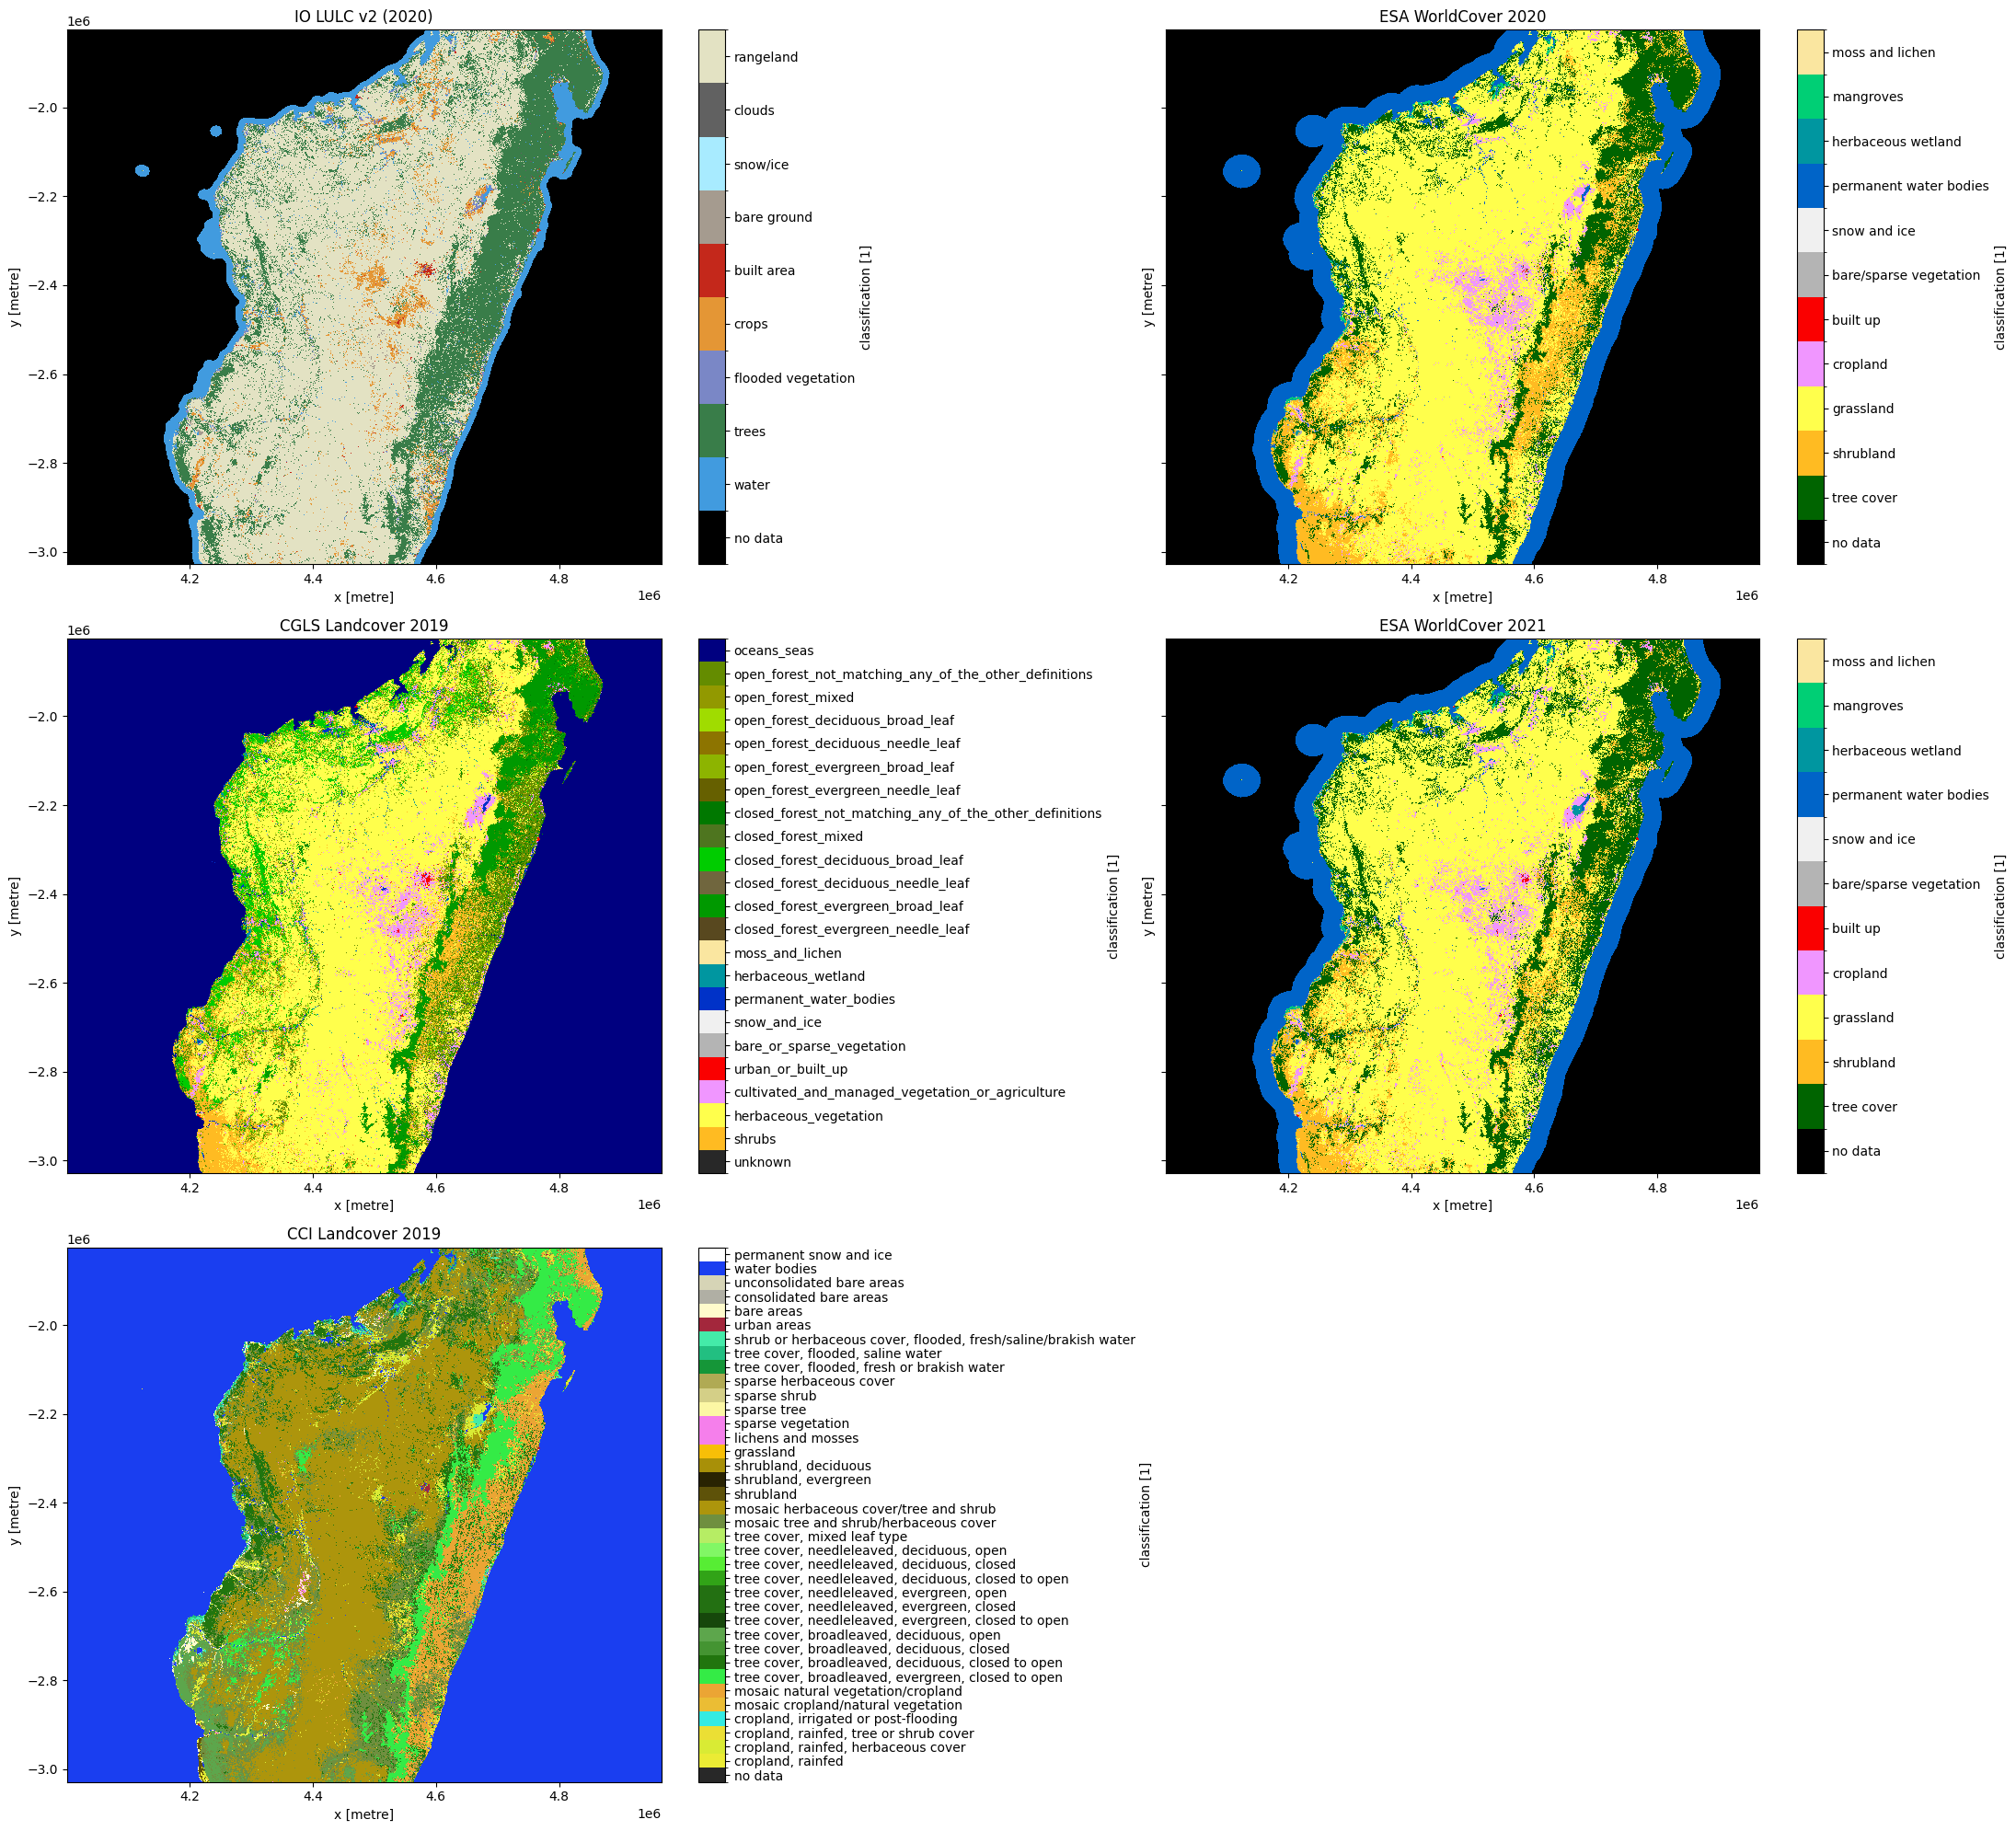

In [15]:
## 2.1.7 Comparer les produits disponibles
#____________________________________________________________

# Comparaison visuelle des résultats de classification

fig, axes = plt.subplots(3, 2, figsize=(22, 20), sharey=True)

 

# Visualiser IO LULC v2

plot_lulc(ds_io[measurements], product="IO", legend=True, ax=axes[0,0])

axes[0,0].set_title("IO LULC v2 (2020)")

 

# Visualiser ESA WorldCover 2020

plot_lulc(ds_esa_2020[measurements], product="ESA", legend=True, ax=axes[0,1])

axes[0,1].set_title("ESA WorldCover 2020")

 

# Visualiser ESA WorldCover 2021

plot_lulc(ds_esa_2021[measurements], product="ESA", legend=True, ax=axes[1,1])

axes[1,1].set_title("ESA WorldCover 2021")

 

# Visualiser CGLS Landcover 2019

plot_lulc(ds_cgls[measurements], product="CGLS", legend=True, ax=axes[1,0])

axes[1,0].set_title("CGLS Landcover 2019")

 

# Visualiser CCI Landcover 2019

plot_lulc(ds_cci[measurements], product="CCI", legend=True, ax=axes[2,0])

axes[2,0].set_title("CCI Landcover 2019")

 

# Supprimer le sous-graphique vide et ajuster la mise en page

fig.delaxes(axes[2,1])

plt.tight_layout()

#____________________________________________________________

#Figure 2.1.1 – Comparaison des principaux produits LULC sur une même zone d’intérêt

#Interprétation:
#Résolution spatiale: WorldCover offre des données à haute résolution (10 m), permettant de détecter des éléments fins tels que les petites clairières, les routes ou les structures isolées. À l’inverse, IO LULC v2 fonctionne à une résolution plus grossière (500 m), généralisant ces éléments détaillés en classes de couverture terrestre plus larges.
#Couverture temporelle: IO LULC v2 compile les informations de couverture terrestre sur plusieurs années pour produire une carte composite unique, ce qui permet de lisser les variations à court terme. En revanche, WorldCover fournit des instantanés annuels, utiles pour les comparaisons d’une année à l’autre, mais nécessitant un traitement manuel pour détecter les changements.
#Différences dans les schémas de classification : les divergences entre les systèmes de classification — par exemple, dans la définition des zones de « broussailles », de « prairies » ou de zones « bâties » — peuvent compliquer les comparaisons directes et rendre les analyses comme la déforestation plus complexes.
#Stratégie affinée 🎯
#Pour faciliter la détection efficace des points chauds, nous optons pour le produit land_cover_change. Contrairement aux cartes statiques, ce produit encode directement l’année de la perte, ce qui simplifie l’analyse, élimine le besoin de comparer manuellement plusieurs cartes et réduit les risques d’erreurs d’interprétation.

In [16]:
## 2.1.8 Utiliser les produits CCI et CGLS pour détecter les changements
#Comme le produit land_cover_change n’est pas indexé dans ce Sandbox, nous allons créer des masques annuels de perte forestière en comparant les classifications d’occupation du sol fournies par les produits CCI et CGLS. Plutôt que d’écrire des fichiers GeoTIFF (ce qui a tendance à faire planter le noyau), nous afficherons chaque masque en ligne, à une résolution plus grossière afin de limiter le temps d’exécution et la consommation de mémoire.

## 2.1.8.1 Paramètres de la zone d’étude et géobox de référence 
#Cette étape unique permet de fixer les paramètres de notre grille spatiale (emprise, système de coordonnées, résolution) en chargeant une seule année de données du produit CCI.
#____________________________________________________________

import datacube, numpy as np, xarray as xr

import matplotlib.pyplot as plt

from matplotlib.patches import Patch

import pandas as pd

 

dc = datacube.Datacube(app="change_detection_production")

 

# Grille 500 m pour l’Afrique de l’Ouest et chargement de CCI 2015 pour la géobox

template_query = {

    'x': (-16.0, 12.0),

    'y': (4.0, 12.0),

    'time': '2015',

    'resolution': (-500, 500),

    'output_crs': 'EPSG:6933'

}

ds_template = dc.load(

    product='cci_landcover',

    measurements=['classification'],

    **template_query

).squeeze()

#____________________________________________________________

#Pourquoi?

#En utilisant l'instruction like=ds_template.geobox à chaque chargement, on garantit un alignement parfait des pixels sans reprojection répétée, tout en travaillant sur une seule grille cohérente et constante.

/tmp/ipykernel_1411/2376211277.py:25: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/2376211277.py:31: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/2376211277.py:25: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/2376211277.py:31: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/2376211277.py:25: DeprecationWarning: Geobox

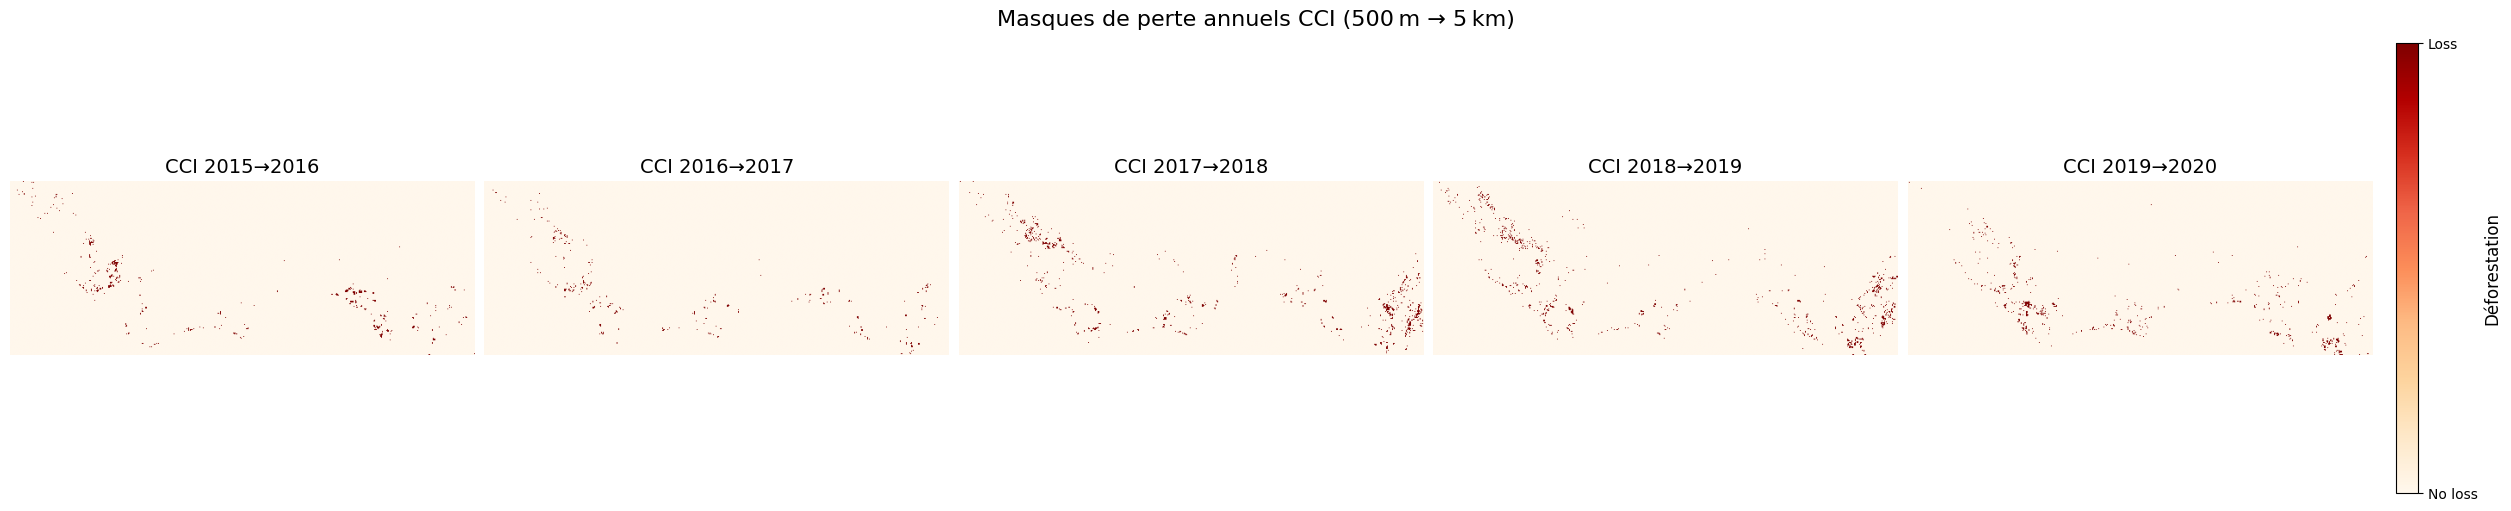

5 masques CCI collectés


In [17]:
## 2.1.8.2 Calcul et visualisation en ligne des masques de perte annuels du CCI
#On affichera cinq petites cartes (2015→2016, …, 2019→2020) à une résolution de 500 m, puis on les réduira d’un facteur 10 ((~ 5 km) pour accélérer l’affichage.
#____________________________________________________________

years        = list(range(2015, 2021))

forest_codes = [50, 60]              # codes de couverture arborée (tree-cover) de CCI 

meas         = 'classification'

 

cci_masks = []

 

fig, axes = plt.subplots(1, len(years)-1, figsize=(5*(len(years)-1), 5), constrained_layout=True)

for ax, (y0, y1) in zip(axes, zip(years[:-1], years[1:])):

    try:

        ds0 = dc.load('cci_landcover', time=str(y0),

                      measurements=[meas], like=ds_template.geobox,

                      skip_broken_datasets=True).squeeze()

        ds1 = dc.load('cci_landcover', time=str(y1),

                      measurements=[meas], like=ds_template.geobox,

                      skip_broken_datasets=True).squeeze()

        da0 = ds0[meas]

        da1 = ds1[meas]

    except Exception as e:

        print(f"Ignorer CCI {y0}→{y1}: {e}")

        continue

 

    mask       = da0.isin(forest_codes) & (~da1.isin(forest_codes))

    mask_small = mask.coarsen(x=10, y=10, boundary='trim').max()

    mask_small = mask_small.expand_dims(time=[pd.to_datetime(f'{y1}-01-01')])

 

    cci_masks.append(mask_small)

 

    im = ax.imshow(mask_small.isel(time=0), cmap='OrRd', vmin=0, vmax=1)

    ax.set_title(f'CCI {y0}→{y1}', fontsize=14)

    ax.set_aspect('equal'); ax.axis('off')

 

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)

cbar.set_ticks([0,1]); cbar.set_ticklabels(['No loss','Loss'])

cbar.set_label('Déforestation', fontsize=12)

fig.suptitle('Masques de perte annuels CCI (500 m → 5 km)', fontsize=16)

plt.show()


print(f"{len(cci_masks)} masques CCI collectés")
#____________________________________________________________

#Astuce: si cette cellule prend trop de temps à s’exécuter, augmentez le facteur de réduction (coarsening) à 20 ou 50 pour alléger davantage les données.

#Figure 2.1.2 – Masques de perte annuels CCI (500 m → 5 km)

/tmp/ipykernel_1411/742308162.py:25: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/742308162.py:31: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/742308162.py:25: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/742308162.py:31: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  measurements=[meas], like=ds_template.geobox,
/tmp/ipykernel_1411/742308162.py:25: DeprecationWarning: Geobox extr

Ignorer CGLS 2019→2020: "No variable named 'classification'. Variables on the dataset include []"


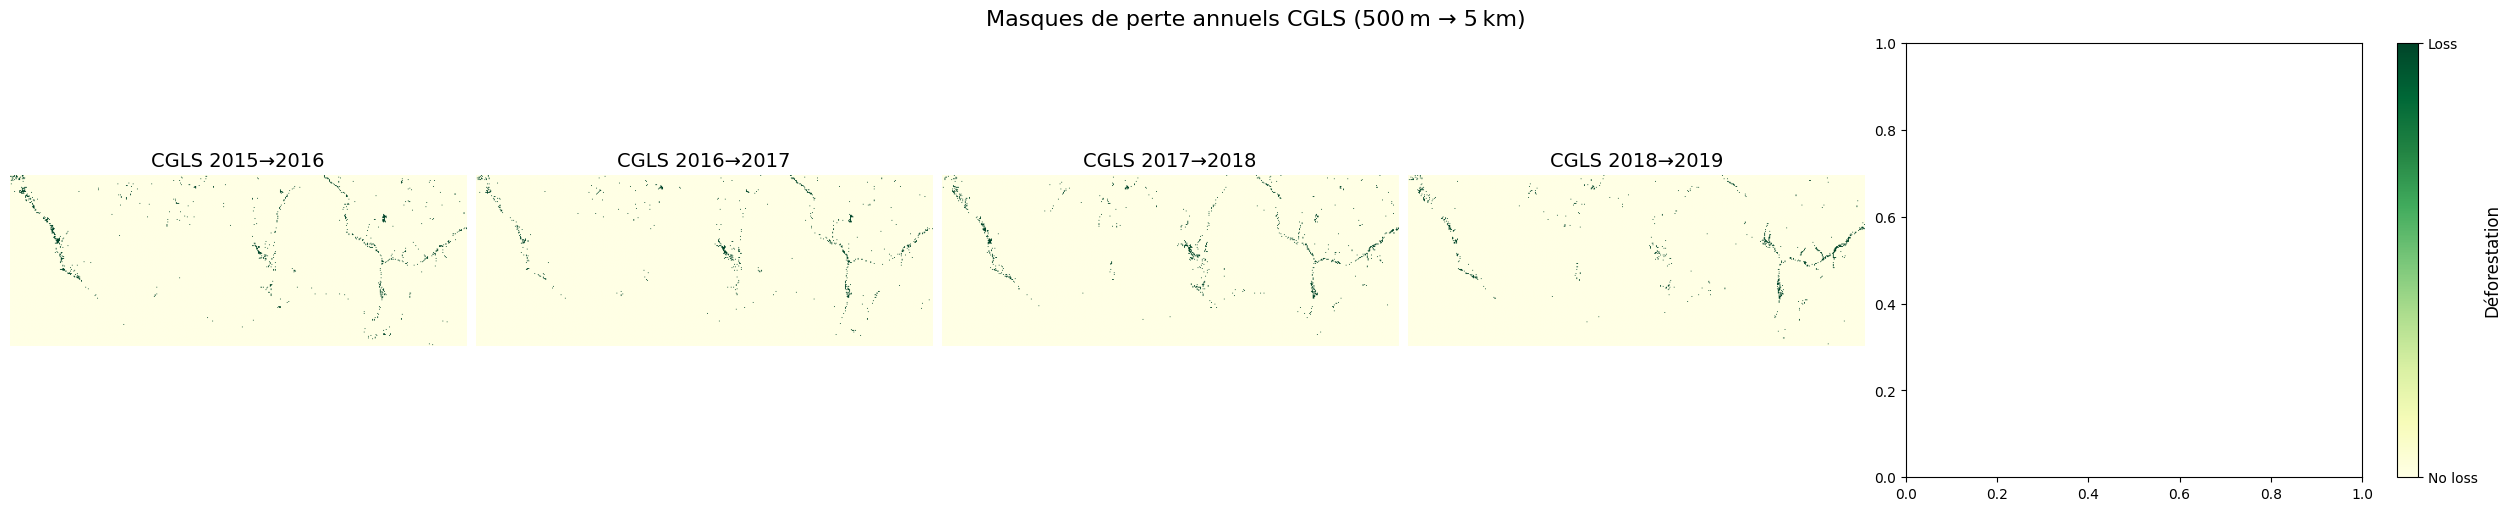

4 masques CGLS collectés


In [18]:
## 2.1.8.3 Calcul et visualisation en ligne des masques de perte annuels du CGLS
#Une approche identique est utilisée pour CGLS — il suffit de remplacer le nom du produit et les codes de couverture arborée.
#____________________________________________________________

years        = list(range(2015, 2021))

forest_codes = [40, 50]              # codes de couverture arborée (tree-cover) de CGLS

meas         = 'classification'

 

cgls_masks = []

 

fig, axes = plt.subplots(1, len(years)-1, figsize=(5*(len(years)-1), 5), constrained_layout=True)

for ax, (y0, y1) in zip(axes, zip(years[:-1], years[1:])):

    try:

        ds0 = dc.load('cgls_landcover', time=str(y0),

                      measurements=[meas], like=ds_template.geobox,

                      skip_broken_datasets=True).squeeze()

        ds1 = dc.load('cgls_landcover', time=str(y1),

                      measurements=[meas], like=ds_template.geobox,

                      skip_broken_datasets=True).squeeze()

        da0 = ds0[meas]

        da1 = ds1[meas]

    except Exception as e:

        print(f"Ignorer CGLS {y0}→{y1}: {e}")

        continue

 

    mask       = da0.isin(forest_codes) & (~da1.isin(forest_codes))

    mask_small = mask.coarsen(x=10, y=10, boundary='trim').max()

    mask_small = mask_small.expand_dims(time=[pd.to_datetime(f'{y1}-01-01')])

 

    cgls_masks.append(mask_small)

 

    im = ax.imshow(mask_small.isel(time=0), cmap='YlGn', vmin=0, vmax=1)

    ax.set_title(f'CGLS {y0}→{y1}', fontsize=14)

    ax.set_aspect('equal'); ax.axis('off')

 

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)

cbar.set_ticks([0,1]); cbar.set_ticklabels(['No loss','Loss'])

cbar.set_label('Déforestation', fontsize=12)

fig.suptitle('Masques de perte annuels CGLS (500 m → 5 km)', fontsize=16)

plt.show()


print(f"{len(cgls_masks)} masques CGLS collectés")
#____________________________________________________________

#Note: chacune de ces deux cellules ne traite qu’un seul produit, mais à une résolution réduite, ce qui permet de limiter le temps d’exécution et de préserver la stabilité du noyau Jupyter.

#Figure 2.1.3 – Masques de perte annuels CGLS (500 m → 5 km)

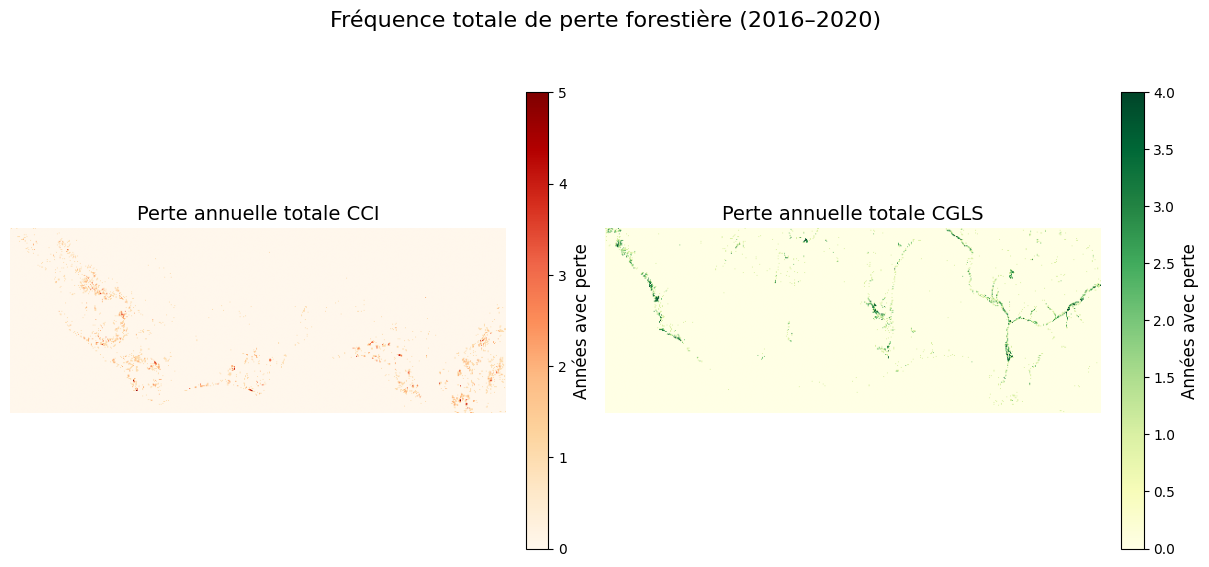

In [19]:
## 2.1.8.4 Cartes des pertes totales
#Enfin, empilez les masques à résolution réduite selon l’axe tempoerel pour calculer, pour chaque pixel, le nombre d’années de perte entre 2016 et 2020, puis affichez-les côte à côte avec des rampes de couleurs contrastées.
#____________________________________________________________

import xarray as xr

import matplotlib.pyplot as plt

import pandas as pd

 

# Assurer la précision temporelle : mettre à jour les coordonnées 'time' dans les masques (précision en nanosecondes)

def ensure_nanosecond_time(masks, years):

    updated_masks = []

    for mask, year in zip(masks, years):

        # Créer un horodatage avec une précision en nanosecondes

        ns_time = pd.to_datetime(f'{year}-01-01')

        # Réassigner la coordonnée en toute sécurité

        mask = mask.expand_dims(time=[ns_time]) if 'time' not in mask.dims else mask.assign_coords(time=[ns_time])

        updated_masks.append(mask)

    return updated_masks

 

years = range(2016, 2021)

cci_masks  = ensure_nanosecond_time(cci_masks, years)

cgls_masks = ensure_nanosecond_time(cgls_masks, years)

 

# Empiler et sommer les masques sous-échantillonnés le long de l’axe temporel

total_cci  = xr.concat(cci_masks,  dim='time').sum(dim='time')

total_cgls = xr.concat(cgls_masks, dim='time').sum(dim='time')

 

# Afficher côte à côte avec des axes carrés

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

 

# Perte totale (CCI)

im0 = ax0.imshow(total_cci, cmap='OrRd', vmin=0, vmax=total_cci.max())

ax0.set_title('Perte annuelle totale CCI', fontsize=14)

ax0.set_aspect('equal')

ax0.axis('off')

c0 = fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

c0.set_label('Années avec perte', fontsize=12)

 

# Perte totale (CGLS) 

im1 = ax1.imshow(total_cgls, cmap='YlGn', vmin=0,  vmax=total_cgls.max())

ax1.set_title('Perte annuelle totale CGLS', fontsize=14)

ax1.set_aspect('equal')

ax1.axis('off')

c1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

c1.set_label('Années avec perte', fontsize=12)

 

# Titre général

fig.suptitle('Fréquence totale de perte forestière (2016–2020)', fontsize=16)

plt.show()

#____________________________________________________________

#Résultat:  vous disposez désormais de cartes claires et légères illustrant la déforestation annuelle et totale liée aux produits CCI et CGLS — prêtes à être interprétées dans la section suivante.
#Figure 2.1.4 – Fréquence totale de perte forestière (2016–2020)

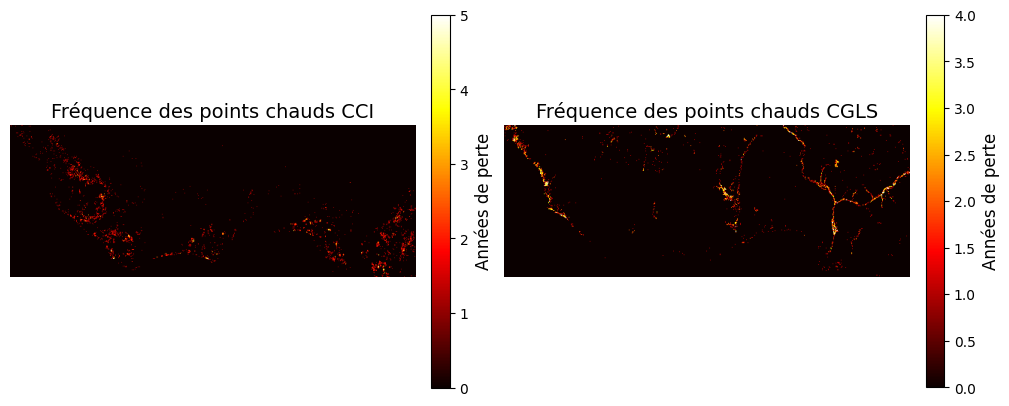

In [20]:
## 2.1.9 Identifier les tendances de perte annuelle
## 2.1.9.1 Calculer et afficher la fréquence des points chauds
#____________________________________________________________
def ensure_nanosecond_time(masks, years):

    updated_masks = []

    for mask, year in zip(masks, years):

        # Force nanosecond-precision datetime

        ns_time = np.datetime64(f'{year}-01-01T00:00:00', 'ns')

        # Expand or assign time

        if 'time' not in mask.coords:

            mask = mask.expand_dims(time=[ns_time])

        else:

            mask = mask.assign_coords(time=[ns_time])

        updated_masks.append(mask)

    return updated_masks

 
years = range(2016, 2021)

cci_masks  = ensure_nanosecond_time(cci_masks, years)

cgls_masks = ensure_nanosecond_time(cgls_masks, years)

 
# Stack & sum to get number of loss‐years per pixel

stack_cci  = xr.concat(cci_masks,  dim='time')

stack_cgls = xr.concat(cgls_masks, dim='time')

 
hot_cci  = stack_cci.sum(dim='time')

hot_cgls = stack_cgls.sum(dim='time')

 
# Plot side-by-side, square maps

fig, (ax0, ax1) = plt.subplots(1,2, figsize=(10,5), constrained_layout=True)

 
im0 = ax0.imshow(hot_cci,  cmap='hot')

ax0.set_title('Fréquence des points chauds CCI', fontsize=14)

ax0.set_aspect('equal'); ax0.axis('off')

c0 = fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

c0.set_label('Années de perte', fontsize=12)

 
im1 = ax1.imshow(hot_cgls, cmap='hot')

ax1.set_title('Fréquence des points chauds CGLS', fontsize=14)

ax1.set_aspect('equal'); ax1.axis('off')

c1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

c1.set_label('Années de perte', fontsize=12)

 
plt.show()

#____________________________________________________________

#Figure 2.1.5 – Cartes thermiques de fréquence de déforestation (CCI vs CGLS)

#Interprétation : les deux produits mettent en évidence les principales zones de défrichement, mais le CCI (résolution native de 10 m) révèle des perturbations à plus petite échelle, ce qui est utile pour identifier l’impact des petits exploitants, tandis que le CGLS (résolution de 100 m) lisse les événements mineurs et accentue la déforestation à grande échelle. Ces variations soulignent l’importance de la résolution et des schémas de classification pour orienter les actions de conservation.🌍

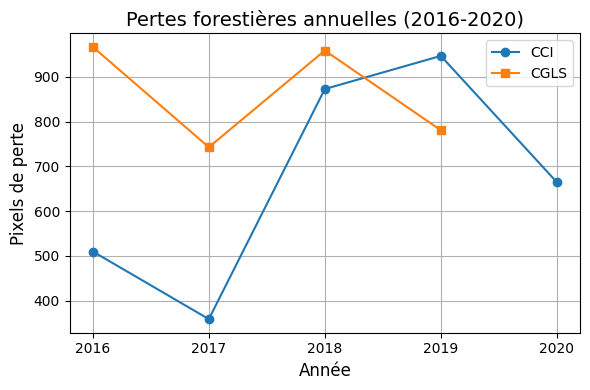

In [21]:
## 2.1.9.2 Série chronologique des pertes annuelles
#____________________________________________________________
# Série temporelle des pertes annuelles (robuste aux dates manquantes)
 
import matplotlib.pyplot as plt

 
# Extraire l’année de chaque masque à partir de la coordonnée temporelle

years_cci  = [int(str(da.time.values[0])[:4]) for da in cci_masks]

years_cgls = [int(str(da.time.values[0])[:4]) for da in cgls_masks]

 
# Compter le nombre total de pixels de perte pour chaque année

counts_cci  = [int(da.sum().item()) for da in cci_masks]

counts_cgls = [int(da.sum().item()) for da in cgls_masks]

 
plt.figure(figsize=(6,4))

plt.plot(years_cci,  counts_cci,  '-o', label='CCI',  markersize=6)

plt.plot(years_cgls, counts_cgls, '-s', label='CGLS', markersize=6)

plt.title('Pertes forestières annuelles (2016-2020)', fontsize=14)

plt.xlabel('Année', fontsize=12)

plt.ylabel('Pixels de perte', fontsize=12)

plt.xticks(years_cci)  # S’assurer que seules les années valides apparaissent

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

#____________________________________________________________

#Figure 2.1.6 – Pertes forestières annuelles (2016-2020)

#Interprétation : les tendances temporelles sont similaires pour les années de pic et de creux, ce qui indique une détection robuste des pics de déforestation. Cependant, le produit CCI affiche systématiquement un nombre de pixels plus élevé durant les années de forte perte, en raison de sa résolution plus fine — un point important à prendre en compte lors de la comparaison des valeurs absolues ou du reporting des totaux. 📈

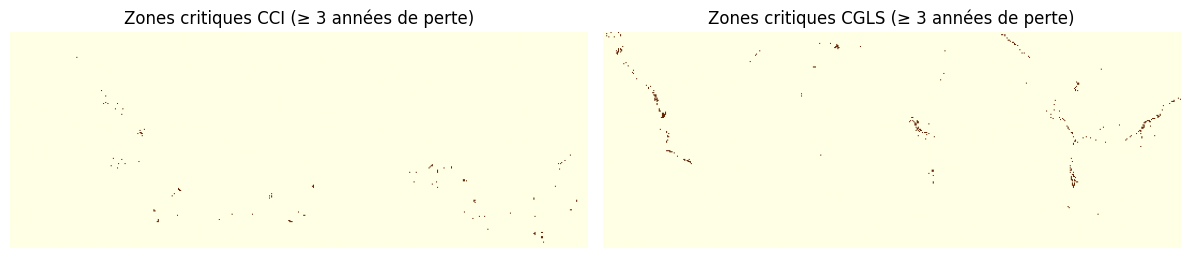

In [22]:
## 2.1.10 Définir les points chauds critiques
#____________________________________________________________

# Module 2.1 – Identifier les pixels déboisés au moins 3 années sur 5

severe_cci  = hot_cci  >= 3

severe_cgls = hot_cgls >= 3

 

# Visaualiser les cartes binaires des zones critiques (“hotspots”) 

fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax2.imshow(severe_cci,  cmap='YlOrBr');  ax2.set_title('Zones critiques CCI (≥ 3 années de perte)');  ax2.axis('off')

ax3.imshow(severe_cgls, cmap='YlOrBr'); ax3.set_title('Zones critiques CGLS (≥ 3 années de perte)'); ax3.axis('off')

plt.tight_layout()

#____________________________________________________________

# 2.1.7 – Zones critiques (≥ 3 années) selon CCI et CGLS

#Interprétation: les pixels blancs indiquent des zones de déforestation chronique, c’est-à-dire des zones déboisées à plusieurs reprises au cours des cinq dernières années. La comparaison des deux produits (CCI et CGLS) permet de repérer les zones prioritaires (forte concordance) et celles faisant l'objet d'incertitudes (divergence), permettant ainsi d'orienter les efforts de validation terrain ou de suivi par satellite.🔍

#Astuce 💡
#Sensibilité du seuil: testez des seuils comme « ≥ 2 » ou « = 5 » années pour voir comment la surface des points chauds s’étend ou se contracte.
#Couches contextuelles: superposez des concessions forestières, des zones protégées ou des terres communautaires pour mieux comprendre les facteurs de la déforestation.
#Validation : En cas de divergence entre les produits, appuyez-vous sur des images à haute résolution ou des observations sur le terrain pour affiner l’interprétation.
#Short Challenge Questions ❓
#Résolution vs précision: en quoi l’utilisation de données à 10 m de résolution pourrait-elle améliorer (ou non) la précision de détection des zones de déforestation par rapport aux données à 30 m ?
#Année de pic: quelle est l’année affichant le taux de perte forestière le plus élevé dans la figure 1.4? Quels facteurs environnementaux ou socio-économiques pourraient expliquer ce pic?
#Implications politiques : si les zones de perte sévère se trouvent à l’intérieur ou à proximité d’une aire protégée nouvellement créée, quelles actions de gestion ou recommandations politiques conviendraient ?